# 00 - Experimentos de balanceo para prediccion de glucosa

Objetivo: comparar tecnicas de balanceo sobre escenarios desbalanceados realistas y verificar cuales se acercan al rendimiento de una referencia entrenada en dataset balanceado.

Criterio clinico prioritario: sensibilidad (recall) en hipoglucemia e hiperglucemia.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    average_precision_score,
)
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)

CLASS_ORDER = ['hypoglycemia', 'normoglycemia', 'hyperglycemia']

LOOKBACK = 24
STRIDE = 12
MAX_WINDOWS_PER_PATIENT = 700
N_PATIENTS_SAMPLE = 180
TRAIN_FRAC = 0.8

RATIO_SCENARIOS = [18, 40, 105]


def find_project_root(start: Path) -> Path:
    for candidate in [start] + list(start.parents):
        if (candidate / 'data' / 'T1DiabetesGranada').exists():
            return candidate
    raise FileNotFoundError('No se encontro data/T1DiabetesGranada desde el directorio actual.')


def glucose_class(value: float) -> str:
    if pd.isna(value):
        return 'missing'
    if value < 70:
        return 'hypoglycemia'
    if value <= 180:
        return 'normoglycemia'
    return 'hyperglycemia'


ROOT = find_project_root(Path.cwd())
DATA_DIR = ROOT / 'data' / 'T1DiabetesGranada'

print('ROOT:', ROOT)
print('DATA_DIR:', DATA_DIR)

ROOT: c:\Users\User\Desktop\TFM-Glucose-Prediction
DATA_DIR: c:\Users\User\Desktop\TFM-Glucose-Prediction\data\T1DiabetesGranada


In [2]:
# 1) Carga de metadata de pacientes y seleccion de muestra de pacientes
patient_info = pd.read_csv(DATA_DIR / 'Patient_info.csv')
if 'Patient_Id' in patient_info.columns and 'Patient_ID' not in patient_info.columns:
    patient_info = patient_info.rename(columns={'Patient_Id': 'Patient_ID'})

patient_info['Number_of_measurements'] = pd.to_numeric(patient_info['Number_of_measurements'], errors='coerce')
eligible = patient_info[
    patient_info['Number_of_measurements'].fillna(0) >= (LOOKBACK + 200)
].copy()

n_select = min(N_PATIENTS_SAMPLE, eligible['Patient_ID'].nunique())
selected_patients = (
    eligible['Patient_ID']
    .dropna()
    .sample(n=n_select, random_state=SEED)
    .tolist()
)
selected_set = set(selected_patients)

print(f'Pacientes elegibles: {eligible.shape[0]}')
print(f'Pacientes seleccionados para experimentos: {len(selected_set)}')

# Demografia minima para features auxiliares
demo_cols = ['Patient_ID']
if 'Sex' in patient_info.columns:
    demo_cols.append('Sex')
if 'Birth_year' in patient_info.columns:
    demo_cols.append('Birth_year')

patient_demo = patient_info[demo_cols].drop_duplicates('Patient_ID').copy()
if 'Birth_year' in patient_demo.columns:
    patient_demo['Age'] = 2022 - pd.to_numeric(patient_demo['Birth_year'], errors='coerce')
else:
    patient_demo['Age'] = np.nan

if 'Sex' in patient_demo.columns:
    patient_demo['Sex_enc'] = patient_demo['Sex'].map({'M': 1, 'F': 0})
else:
    patient_demo['Sex_enc'] = np.nan

patient_demo['Age'] = patient_demo['Age'].fillna(patient_demo['Age'].median())
patient_demo['Sex_enc'] = patient_demo['Sex_enc'].fillna(patient_demo['Sex_enc'].median() if patient_demo['Sex_enc'].notna().any() else 0)

patient_demo = patient_demo[['Patient_ID', 'Age', 'Sex_enc']]

Pacientes elegibles: 736
Pacientes seleccionados para experimentos: 180


In [3]:
# 2) Carga filtrada de glucosa en chunks para no saturar memoria
usecols = ['Patient_ID', 'Measurement_date', 'Measurement_time', 'Measurement']
chunks = []

for chunk in pd.read_csv(
    DATA_DIR / 'Glucose_measurements.csv',
    usecols=usecols,
    chunksize=1_000_000,
):
    chunk = chunk[chunk['Patient_ID'].isin(selected_set)]
    if not chunk.empty:
        chunks.append(chunk)

if len(chunks) == 0:
    raise RuntimeError('No se recuperaron mediciones para los pacientes seleccionados.')

glucose = pd.concat(chunks, ignore_index=True)
del chunks

glucose['Measurement'] = pd.to_numeric(glucose['Measurement'], errors='coerce')
glucose = glucose.dropna(subset=['Measurement'])
glucose['class_label'] = glucose['Measurement'].apply(glucose_class)
glucose = glucose[glucose['class_label'].isin(CLASS_ORDER)].copy()

# Orden temporal por paciente
sort_cols = ['Patient_ID', 'Measurement_date', 'Measurement_time']
glucose = glucose.sort_values(sort_cols).reset_index(drop=True)

glucose = glucose.merge(patient_demo, on='Patient_ID', how='left')

print('Filas de glucosa cargadas (pacientes seleccionados):', glucose.shape[0])
display(glucose.head(3))

class_dist_loaded = glucose['class_label'].value_counts().reindex(CLASS_ORDER, fill_value=0)
display(class_dist_loaded.to_frame('count'))

Filas de glucosa cargadas (pacientes seleccionados): 5600854


,Patient_ID,Measurement_date,Measurement_time,Measurement,class_label,Age,Sex_enc
0,LIB193265,2019-01-27,10:52:00,181,hyperglycemia,42,0
1,LIB193265,2019-01-27,11:07:00,199,hyperglycemia,42,0
2,LIB193265,2019-01-27,11:22:00,243,hyperglycemia,42,0


,count
class_label,
hypoglycemia,307735
normoglycemia,3433796
hyperglycemia,1859323


In [4]:
# 3) Generacion de dataset de ventanas temporales (lookback = 24)
def build_windows_for_patient(df_p: pd.DataFrame, lookback: int, stride: int, max_windows: int, seed: int):
    values = df_p['Measurement'].values.astype(float)
    labels = df_p['class_label'].values
    age = float(df_p['Age'].iloc[0]) if 'Age' in df_p.columns else np.nan
    sex_enc = float(df_p['Sex_enc'].iloc[0]) if 'Sex_enc' in df_p.columns else 0.0

    idx_candidates = np.arange(lookback, len(df_p), stride)
    if len(idx_candidates) == 0:
        return []

    if len(idx_candidates) > max_windows:
        rng = np.random.default_rng(seed)
        idx_candidates = np.sort(rng.choice(idx_candidates, size=max_windows, replace=False))

    rows = []
    for i in idx_candidates:
        window = values[i - lookback:i]
        y = labels[i]

        feat = {
            'Patient_ID': df_p['Patient_ID'].iloc[0],
            'y': y,
            'Age': age,
            'Sex_enc': sex_enc,
            'w_mean': float(np.mean(window)),
            'w_std': float(np.std(window)),
            'w_min': float(np.min(window)),
            'w_max': float(np.max(window)),
            'w_slope': float(np.polyfit(np.arange(lookback), window, 1)[0]),
        }
        for k, v in enumerate(window, start=1):
            feat[f'lag_{lookback - k + 1}'] = float(v)

        rows.append(feat)

    return rows

window_rows = []
for pid, df_p in glucose.groupby('Patient_ID', sort=False):
    df_p = df_p.reset_index(drop=True)
    if len(df_p) < LOOKBACK + 30:
        continue
    rows = build_windows_for_patient(
        df_p=df_p,
        lookback=LOOKBACK,
        stride=STRIDE,
        max_windows=MAX_WINDOWS_PER_PATIENT,
        seed=SEED,
    )
    window_rows.extend(rows)

windows_df = pd.DataFrame(window_rows)
if windows_df.empty:
    raise RuntimeError('No se generaron ventanas. Ajusta N_PATIENTS_SAMPLE / STRIDE / MAX_WINDOWS_PER_PATIENT.')

print('Muestras (ventanas) generadas:', windows_df.shape[0])
display(windows_df.head(2))

print('Distribucion de clases en ventanas:')
display(windows_df['y'].value_counts().reindex(CLASS_ORDER, fill_value=0).to_frame('count'))

Muestras (ventanas) generadas: 111648


,Patient_ID,y,Age,Sex_enc,w_mean,w_std,w_min,w_max,w_slope,lag_24,lag_23,lag_22,lag_21,lag_20,lag_19,lag_18,lag_17,lag_16,lag_15,lag_14,lag_13,lag_12,lag_11,lag_10,lag_9,lag_8,lag_7,lag_6,lag_5,lag_4,lag_3,lag_2,lag_1
0,LIB193265,normoglycemia,42.0,0.0,138.375000,37.778756,91.0,213.0,2.982174,112.0,101.0,91.0,99.0,102.0,104.0,111.0,114.0,116.0,118.0,124.0,130.0,148.0,185.0,205.0,212.0,213.0,192.0,176.0,158.0,142.0,133.0,122.0,113.0
1,LIB193265,normoglycemia,42.0,0.0,133.916667,45.905625,48.0,178.0,4.673043,56.0,57.0,56.0,50.0,48.0,77.0,132.0,158.0,165.0,167.0,172.0,178.0,175.0,174.0,173.0,160.0,149.0,141.0,138.0,147.0,153.0,161.0,164.0,163.0


Distribucion de clases en ventanas:


,count
y,
hypoglycemia,5349
normoglycemia,66318
hyperglycemia,39981


In [5]:
# 4) Split temporal por paciente (evita leakage entre pasado/futuro)
train_parts = []
test_parts = []

for pid, df_p in windows_df.groupby('Patient_ID', sort=False):
    n = len(df_p)
    if n < 20:
        continue
    cut = int(n * TRAIN_FRAC)
    cut = max(10, min(cut, n - 5))

    train_parts.append(df_p.iloc[:cut])
    test_parts.append(df_p.iloc[cut:])

train_df = pd.concat(train_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)

feature_cols = [c for c in train_df.columns if c not in ['Patient_ID', 'y']]

X_train = train_df[feature_cols].values
y_train = train_df['y'].values
X_test = test_df[feature_cols].values
y_test = test_df['y'].values

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

print('\nDistribucion Train:')
display(train_df['y'].value_counts().reindex(CLASS_ORDER, fill_value=0).to_frame('count'))

print('\nDistribucion Test:')
display(test_df['y'].value_counts().reindex(CLASS_ORDER, fill_value=0).to_frame('count'))

Train shape: (89303, 31)
Test shape: (22345, 31)

Distribucion Train:


,count
y,
hypoglycemia,4379
normoglycemia,53336
hyperglycemia,31588



Distribucion Test:


,count
y,
hypoglycemia,970
normoglycemia,12982
hyperglycemia,8393


In [6]:
# 5) Funciones auxiliares para escenarios y evaluacion

def class_distribution(y):
    s = pd.Series(y)
    return s.value_counts().reindex(CLASS_ORDER, fill_value=0)


def make_balanced_reference(X, y, seed=SEED):
    s = pd.Series(y)
    n_min = int(s.value_counts().min())
    idx_all = []
    rng = np.random.default_rng(seed)

    for c in CLASS_ORDER:
        idx_c = np.where(y == c)[0]
        idx_sel = rng.choice(idx_c, size=n_min, replace=False)
        idx_all.append(idx_sel)

    idx_all = np.concatenate(idx_all)
    rng.shuffle(idx_all)
    return X[idx_all], y[idx_all]


def make_ratio_scenario(X, y, target_ratio, seed=SEED):
    """Construye escenario con ratio aprox normoglycemia:minoritarias = target_ratio:1."""
    s = pd.Series(y)
    rng = np.random.default_rng(seed)

    idx_normo = np.where(y == 'normoglycemia')[0]
    n_normo = len(idx_normo)

    idx_selected = [idx_normo]

    for c in ['hypoglycemia', 'hyperglycemia']:
        idx_c = np.where(y == c)[0]
        target_n = max(50, int(n_normo / target_ratio))
        target_n = min(target_n, len(idx_c))
        idx_sel = rng.choice(idx_c, size=target_n, replace=False)
        idx_selected.append(idx_sel)

    idx = np.concatenate(idx_selected)
    rng.shuffle(idx)
    return X[idx], y[idx]


def build_model(strategy_name, seed=SEED):
    clf = RandomForestClassifier(
        n_estimators=180,
        max_depth=16,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=seed,
    )

    if strategy_name == 'none':
        return clf
    if strategy_name == 'class_weight':
        return RandomForestClassifier(
            n_estimators=180,
            max_depth=16,
            min_samples_leaf=2,
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=seed,
        )
    if strategy_name == 'random_undersample':
        return ImbPipeline([
            ('sampler', RandomUnderSampler(sampling_strategy='not minority', random_state=seed)),
            ('model', clf),
        ])
    if strategy_name == 'random_oversample':
        return ImbPipeline([
            ('sampler', RandomOverSampler(sampling_strategy='not majority', random_state=seed)),
            ('model', clf),
        ])
    if strategy_name == 'smote':
        return ImbPipeline([
            ('sampler', SMOTE(sampling_strategy='not majority', k_neighbors=3, random_state=seed)),
            ('model', clf),
        ])

    raise ValueError(f'Estrategia no soportada: {strategy_name}')


def evaluate_experiment(model, Xtr, ytr, Xte, yte, scenario, strategy):
    t0 = time.time()
    model.fit(Xtr, ytr)
    fit_seconds = time.time() - t0

    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)

    proba_df = pd.DataFrame(proba, columns=model.classes_)

    yte_bin_hypo = (yte == 'hypoglycemia').astype(int)
    yte_bin_hyper = (yte == 'hyperglycemia').astype(int)

    row = {
        'scenario': scenario,
        'strategy': strategy,
        'fit_seconds': fit_seconds,
        'balanced_accuracy': balanced_accuracy_score(yte, pred),
        'f1_macro': f1_score(yte, pred, average='macro', zero_division=0),
        'recall_hypoglycemia': recall_score(yte, pred, labels=['hypoglycemia'], average='macro', zero_division=0),
        'recall_hyperglycemia': recall_score(yte, pred, labels=['hyperglycemia'], average='macro', zero_division=0),
        'precision_hypoglycemia': precision_score(yte, pred, labels=['hypoglycemia'], average='macro', zero_division=0),
        'precision_hyperglycemia': precision_score(yte, pred, labels=['hyperglycemia'], average='macro', zero_division=0),
        'pr_auc_hypoglycemia': average_precision_score(yte_bin_hypo, proba_df['hypoglycemia']),
        'pr_auc_hyperglycemia': average_precision_score(yte_bin_hyper, proba_df['hyperglycemia']),
    }
    return row

In [7]:
# 6) Experimento de referencia: train balanceado (benchmark objetivo)
X_ref, y_ref = make_balanced_reference(X_train, y_train, seed=SEED)

print('Distribucion referencia balanceada:')
display(class_distribution(y_ref).to_frame('count'))

ref_model = build_model('none', seed=SEED)
reference_result = evaluate_experiment(
    model=ref_model,
    Xtr=X_ref,
    ytr=y_ref,
    Xte=X_test,
    yte=y_test,
    scenario='balanced_reference',
    strategy='none',
)

reference_df = pd.DataFrame([reference_result])
display(reference_df)

Distribucion referencia balanceada:


,count
hypoglycemia,4379
normoglycemia,4379
hyperglycemia,4379


,scenario,strategy,fit_seconds,balanced_accuracy,f1_macro,recall_hypoglycemia,recall_hyperglycemia,precision_hypoglycemia,precision_hyperglycemia,pr_auc_hypoglycemia,pr_auc_hyperglycemia
0,balanced_reference,none,1.182219,0.931231,0.86595,0.940206,0.947695,0.592978,0.929423,0.816368,0.981087


In [8]:
# 7) Escenarios desbalanceados realistas + tecnicas de balanceo
strategies = ['none', 'class_weight', 'random_undersample', 'random_oversample', 'smote']
rows = []

for ratio in RATIO_SCENARIOS:
    X_sc, y_sc = make_ratio_scenario(X_train, y_train, target_ratio=ratio, seed=SEED)

    print(f'\nEscenario ratio objetivo normo:minoritarias ~ {ratio}:1')
    display(class_distribution(y_sc).to_frame('count'))

    for strategy in strategies:
        model = build_model(strategy, seed=SEED)
        result = evaluate_experiment(
            model=model,
            Xtr=X_sc,
            ytr=y_sc,
            Xte=X_test,
            yte=y_test,
            scenario=f'ratio_{ratio}_to_1',
            strategy=strategy,
        )
        rows.append(result)
        print(f"Completado -> ratio {ratio}:1 | estrategia {strategy}")

results_df = pd.DataFrame(rows)
display(results_df.head())


Escenario ratio objetivo normo:minoritarias ~ 18:1


,count
hypoglycemia,2963
normoglycemia,53336
hyperglycemia,2963


Completado -> ratio 18:1 | estrategia none
Completado -> ratio 18:1 | estrategia class_weight
Completado -> ratio 18:1 | estrategia random_undersample
Completado -> ratio 18:1 | estrategia random_oversample
Completado -> ratio 18:1 | estrategia smote

Escenario ratio objetivo normo:minoritarias ~ 40:1


,count
hypoglycemia,1333
normoglycemia,53336
hyperglycemia,1333


Completado -> ratio 40:1 | estrategia none
Completado -> ratio 40:1 | estrategia class_weight
Completado -> ratio 40:1 | estrategia random_undersample
Completado -> ratio 40:1 | estrategia random_oversample
Completado -> ratio 40:1 | estrategia smote

Escenario ratio objetivo normo:minoritarias ~ 105:1


,count
hypoglycemia,507
normoglycemia,53336
hyperglycemia,507


Completado -> ratio 105:1 | estrategia none
Completado -> ratio 105:1 | estrategia class_weight
Completado -> ratio 105:1 | estrategia random_undersample
Completado -> ratio 105:1 | estrategia random_oversample
Completado -> ratio 105:1 | estrategia smote


,scenario,strategy,fit_seconds,balanced_accuracy,f1_macro,recall_hypoglycemia,recall_hyperglycemia,precision_hypoglycemia,precision_hyperglycemia,pr_auc_hypoglycemia,pr_auc_hyperglycemia
0,ratio_18_to_1,none,7.106273,0.833156,0.858440,0.711340,0.803765,0.826347,0.990893,0.843050,0.981485
1,ratio_18_to_1,class_weight,6.457666,0.882314,0.879598,0.817526,0.861075,0.761036,0.977414,0.837319,0.983795
2,ratio_18_to_1,random_undersample,0.881148,0.929704,0.856195,0.945361,0.944120,0.560171,0.930375,0.799972,0.979325
3,ratio_18_to_1,random_oversample,19.769054,0.894501,0.884421,0.840206,0.879423,0.745654,0.974004,0.842551,0.983894
4,ratio_18_to_1,smote,32.000762,0.907588,0.889677,0.862887,0.901704,0.731004,0.969262,0.840834,0.983721


In [9]:
# 8) Comparacion contra referencia balanceada y ranking de tecnicas
all_results = pd.concat([reference_df, results_df], ignore_index=True)

ref = reference_df.iloc[0]
for metric in ['balanced_accuracy', 'f1_macro', 'recall_hypoglycemia', 'recall_hyperglycemia', 'pr_auc_hypoglycemia', 'pr_auc_hyperglycemia']:
    all_results[f'delta_vs_ref_{metric}'] = all_results[metric] - ref[metric]

# Distancia agregada a la referencia (cuanto mas cerca de 0 mejor)
key_metrics = [
    'balanced_accuracy',
    'recall_hypoglycemia',
    'recall_hyperglycemia',
    'pr_auc_hypoglycemia',
    'pr_auc_hyperglycemia',
]

def distance_to_ref(row):
    return float(np.mean([abs(row[m] - ref[m]) for m in key_metrics]))

all_results['distance_to_reference'] = all_results.apply(distance_to_ref, axis=1)

comparison_table = all_results.sort_values(['scenario', 'distance_to_reference'])
display(comparison_table)

best_by_scenario = (
    all_results[all_results['scenario'] != 'balanced_reference']
    .sort_values(['scenario', 'distance_to_reference'])
    .groupby('scenario', as_index=False)
    .first()
)

display(Markdown('### Mejor tecnica por escenario (mas cercana a la referencia balanceada)'))
display(best_by_scenario[['scenario', 'strategy', 'distance_to_reference', 'recall_hypoglycemia', 'recall_hyperglycemia', 'pr_auc_hypoglycemia', 'pr_auc_hyperglycemia']])

,scenario,strategy,fit_seconds,balanced_accuracy,f1_macro,recall_hypoglycemia,recall_hyperglycemia,precision_hypoglycemia,precision_hyperglycemia,pr_auc_hypoglycemia,pr_auc_hyperglycemia,delta_vs_ref_balanced_accuracy,delta_vs_ref_f1_macro,delta_vs_ref_recall_hypoglycemia,delta_vs_ref_recall_hyperglycemia,delta_vs_ref_pr_auc_hypoglycemia,delta_vs_ref_pr_auc_hyperglycemia,distance_to_reference
0,balanced_reference,none,1.182219,0.931231,0.865950,0.940206,0.947695,0.592978,0.929423,0.816368,0.981087,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
13,ratio_105_to_1,random_undersample,0.417428,0.918548,0.836273,0.940206,0.927440,0.514382,0.927882,0.762667,0.966276,-0.012683,-0.029677,0.000000,-0.020255,-0.053701,-0.014812,0.020290
15,ratio_105_to_1,smote,30.272835,0.836212,0.850461,0.729897,0.805314,0.767896,0.980418,0.797523,0.976429,-0.095019,-0.015489,-0.210309,-0.142381,-0.018845,-0.004658,0.094242
14,ratio_105_to_1,random_oversample,19.588739,0.815941,0.838275,0.695876,0.772668,0.782155,0.987062,0.797479,0.975875,-0.115290,-0.027675,-0.244330,-0.175027,-0.018889,-0.005212,0.111750
12,ratio_105_to_1,class_weight,5.032457,0.775148,0.809238,0.622680,0.719171,0.792651,0.990320,0.795200,0.972590,-0.156083,-0.056711,-0.317526,-0.228524,-0.021168,-0.008497,0.146360
11,ratio_105_to_1,none,7.034527,0.603798,0.654388,0.222680,0.590254,0.955752,0.997784,0.808083,0.971894,-0.327433,-0.211561,-0.717526,-0.357441,-0.008285,-0.009193,0.283976
3,ratio_18_to_1,random_undersample,0.881148,0.929704,0.856195,0.945361,0.944120,0.560171,0.930375,0.799972,0.979325,-0.001527,-0.009754,0.005155,-0.003574,-0.016396,-0.001762,0.005683
5,ratio_18_to_1,smote,32.000762,0.907588,0.889677,0.862887,0.901704,0.731004,0.969262,0.840834,0.983721,-0.023643,0.023727,-0.077320,-0.045991,0.024466,0.002634,0.034811
4,ratio_18_to_1,random_oversample,19.769054,0.894501,0.884421,0.840206,0.879423,0.745654,0.974004,0.842551,0.983894,-0.036730,0.018471,-0.100000,-0.068271,0.026183,0.002807,0.046798
2,ratio_18_to_1,class_weight,6.457666,0.882314,0.879598,0.817526,0.861075,0.761036,0.977414,0.837319,0.983795,-0.048917,0.013648,-0.122680,-0.086620,0.020952,0.002708,0.056375


### Mejor tecnica por escenario (mas cercana a la referencia balanceada)

,scenario,strategy,distance_to_reference,recall_hypoglycemia,recall_hyperglycemia,pr_auc_hypoglycemia,pr_auc_hyperglycemia
0,ratio_105_to_1,random_undersample,0.020290,0.940206,0.927440,0.762667,0.966276
1,ratio_18_to_1,random_undersample,0.005683,0.945361,0.944120,0.799972,0.979325
2,ratio_40_to_1,random_undersample,0.010118,0.942268,0.943048,0.783613,0.975801


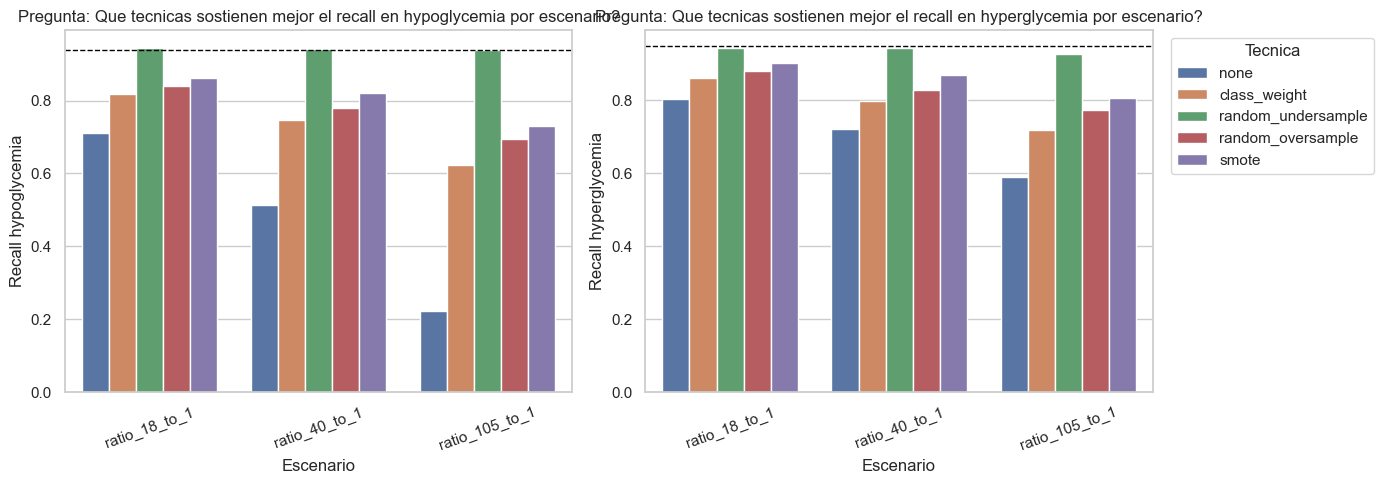

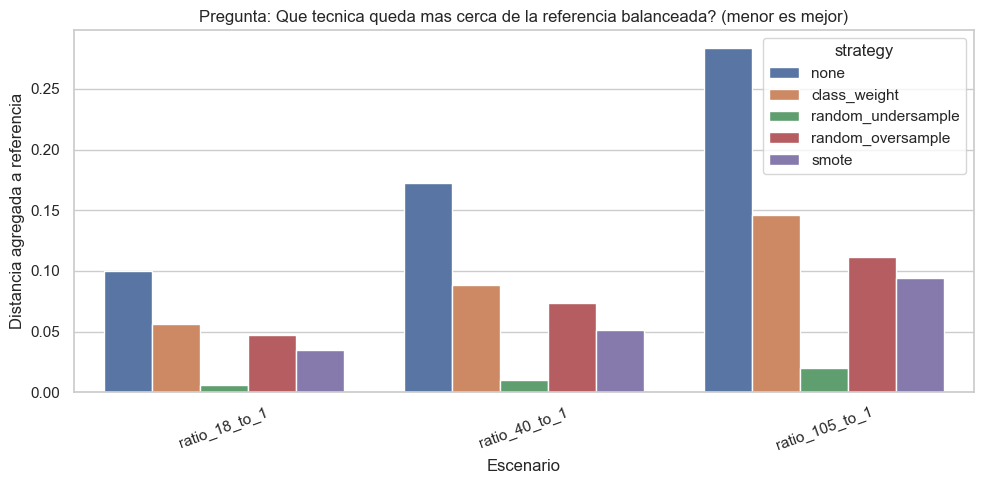

In [10]:
# 9) Visualizaciones de decision
plot_df = all_results[all_results['scenario'] != 'balanced_reference'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=plot_df, x='scenario', y='recall_hypoglycemia', hue='strategy', ax=axes[0])
axes[0].axhline(ref['recall_hypoglycemia'], color='black', linestyle='--', linewidth=1)
axes[0].set_title('Pregunta: Que tecnicas sostienen mejor el recall en hypoglycemia por escenario?')
axes[0].set_ylabel('Recall hypoglycemia')
axes[0].set_xlabel('Escenario')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=plot_df, x='scenario', y='recall_hyperglycemia', hue='strategy', ax=axes[1])
axes[1].axhline(ref['recall_hyperglycemia'], color='black', linestyle='--', linewidth=1)
axes[1].set_title('Pregunta: Que tecnicas sostienen mejor el recall en hyperglycemia por escenario?')
axes[1].set_ylabel('Recall hyperglycemia')
axes[1].set_xlabel('Escenario')
axes[1].tick_params(axis='x', rotation=20)

handles, labels = axes[1].get_legend_handles_labels()
axes[0].legend_.remove()
axes[1].legend(handles, labels, title='Tecnica', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_df, x='scenario', y='distance_to_reference', hue='strategy', ax=ax)
ax.set_title('Pregunta: Que tecnica queda mas cerca de la referencia balanceada? (menor es mejor)')
ax.set_ylabel('Distancia agregada a referencia')
ax.set_xlabel('Escenario')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [11]:
# 10) Conclusiones automaticas para el diseño experimental

winners = best_by_scenario[['scenario', 'strategy', 'distance_to_reference']].copy()

majority_winner = winners['strategy'].mode().iloc[0] if not winners.empty else 'sin ganador'
mean_dist_by_strategy = (
    all_results[all_results['scenario'] != 'balanced_reference']
    .groupby('strategy', as_index=False)['distance_to_reference']
    .mean()
    .sort_values('distance_to_reference')
)

display(Markdown('## Insights para el diseño experimental (Experimentos)'))

insights_md = f"""
### Tecnica con mejor robustez global
- Ganador mas frecuente por escenario: **{majority_winner}**.
- Ranking promedio de cercania a referencia (menor mejor):
"""

display(Markdown(insights_md))
display(mean_dist_by_strategy)

risk_md = """
### Riesgos observados en los experimentos
- A ratios muy extremos, las tecnicas no temporales tienden a degradar recall de hipoglucemia.
- SMOTE clasico puede distorsionar la geometria temporal de ventanas si no se valida por paciente.
- El split debe mantenerse cronologico por paciente para evitar leakage.
"""
display(Markdown(risk_md))

next_md = """
### Recomendacion operativa para la fase final
1. Usar lookback = 24 como configuracion base.
2. Priorizar la tecnica ganadora de robustez y comparar contra una alternativa temporal.
3. Reportar siempre recall de hypoglycemia e hyperglycemia junto con PR-AUC por clase.
4. Mantener evaluacion por paciente ademas de metrica global.
"""
display(Markdown(next_md))

## Insights para el diseño experimental (Experimentos)


### Tecnica con mejor robustez global
- Ganador mas frecuente por escenario: **random_undersample**.
- Ranking promedio de cercania a referencia (menor mejor):


,strategy,distance_to_reference
3,random_undersample,0.012030
4,smote,0.060057
2,random_oversample,0.077448
0,class_weight,0.096905
1,none,0.185266



### Riesgos observados en los experimentos
- A ratios muy extremos, las tecnicas no temporales tienden a degradar recall de hipoglucemia.
- SMOTE clasico puede distorsionar la geometria temporal de ventanas si no se valida por paciente.
- El split debe mantenerse cronologico por paciente para evitar leakage.



### Recomendacion operativa para la fase final
1. Usar lookback = 24 como configuracion base.
2. Priorizar la tecnica ganadora de robustez y comparar contra una alternativa temporal.
3. Reportar siempre recall de hypoglycemia e hyperglycemia junto con PR-AUC por clase.
4. Mantener evaluacion por paciente ademas de metrica global.
